In [1]:
# CS 8803 OAN - Applied Natural Language Processing
# Toolbox #2 - Word2Vec
# Created by: ANLP Instruction Team
# Last Edit: 11/22/2023

# Toolbox #2: Exploring Word2Vec, CBOW and SkipGram

In [9]:
TRAIN_MODELS = True

Error in callback <function set_css at 0x13285f100> (for pre_run_cell), with arguments args (<ExecutionInfo object at 15f690c50, raw_cell="TRAIN_MODELS = True" store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/word2vec-%20CBOW%2C%20SkipGram.ipynb#W2sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

## Introduction and Setup

### Word Embeddings

Word embeddings are representations of words as numerical vectors. Ideally, we would want to create an d-dimensional embedding space for all the words in the language such that:
1) d is as small as possible (to avoid the curse of dimensionality)
2) The mathematical properties of the vectors have "meaning"

Embuing "meaning" into embeddings allows us to take advantage of the mathematical properties of vectors to perform important NLP tasks, such as:
- "word arithmetic": king - man + woman = queen
- finding how similar two words are using distance between embeddings ([Semantle](https://semantle.com/))
- autofill/text prediction using context
- clustering techniques
- sentence generation
- etc.

Let's explore one simple word embedding technique, Word2Vec, and see how well we can do!

### Imports

In [3]:
import sys
import matplotlib
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
import time

print('Version information')

print('python: {}'.format(sys.version))
print('matplotlib: {}'.format(matplotlib.__version__))
print('numpy: {}'.format(np.__version__))

%load_ext autoreload
%autoreload 2
%reload_ext autoreload

## This wraps output text according to the window size
from IPython.display import HTML, display

def set_css():
  display(HTML('''
  <style>
    pre {
        white-space: pre-wrap;
    }
  </style>
  '''))
get_ipython().events.register('pre_run_cell', set_css)

Version information
python: 3.13.1 (v3.13.1:06714517797, Dec  3 2024, 14:00:22) [Clang 15.0.0 (clang-1500.3.9.4)]
matplotlib: 3.10.8
numpy: 2.4.1


Word2Vec Imports

[Gensim](https://pypi.org/project/gensim/) is a free, python library for a variety of NLP models. We will use their Word2Vec model, whose documentation can be found [here](https://radimrehurek.com/gensim/models/word2vec.html). We'll also use [Spacy](https://spacy.io/) for text preprocessing.

In [4]:
%pip install gensim
%pip install spacy


from gensim.models import Word2Vec
import gensim.downloader
print('gensim: {}'.format(gensim.__version__))
import spacy

Error in callback <function set_css at 0x13285f100> (for pre_run_cell), with arguments args (<ExecutionInfo object at 10636a470, raw_cell="%pip install gensim
%pip install spacy


from gens.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/word2vec-%20CBOW%2C%20SkipGram.ipynb#X12sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
gensim: 4.4.0


## Word2Vec

Word2Vec is a group of related models that produce word embeddings using context. Word2vec can utilize either of two model architectures to produce these distributed representations of words: continuous bag-of-words (CBOW) or continuous skip-gram (SG). In both architectures, Word2Vec considers both individual words and a sliding window of context words surrounding these individual words as it iterates over the entire corpus. In CBOW, the model predicts the current word from the context words. SG does the opposite, predicting the context words using the surrounding words.

Word2Vec, when trained on a large corpus, has been shown to be effective time and time again as a lightweight, quick-training NLP model that can generate word embeddings of high quality. It is often the first step taken when addressing an NLP problem. Let's take a look at at Word2Vec and analyze some of its strengths and weaknesses. We'll take a look at training it on the same [fetch20](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_20newsgroups.html) newsgroup dataset we did in the previous toolbox and see how it does. We'll also look at a Word2Vec model that was trained on a much larger dataset to see the full potential of Word2Vec.

### Dataset Setup

Let's import our fetch20 newsgroups dataset. 

In [5]:
train = fetch_20newsgroups(subset='train')
print(len(train.data))

Error in callback <function set_css at 0x13285f100> (for pre_run_cell), with arguments args (<ExecutionInfo object at 152507350, raw_cell="train = fetch_20newsgroups(subset='train')
print(l.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/word2vec-%20CBOW%2C%20SkipGram.ipynb#X20sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

11314


Let's do some quick preprocessing. Let's make a method to split into sentences using Spacy and split sentences into lists of words for input into the Word2Vec model. We'll also create an iterator to pass the data into the Word2Vec model in a memory-efficient way.  

In [7]:
from tqdm import tqdm
import spacy

nlp = spacy.load('en_core_web_sm')

def preprocess(data):
    try:
        sentences = data.split("\n\n\n")[1]
    except:
        sentences = data
    if len(sentences) == 0:
        sentences = data
    try:
        sentences = [str(sent) for sent in nlp(sentences).sents]
        
    except:
        sentences = sentences.split('.')
        print("not using spacy")
        print(sentences)
    sentences = [sent.lower().strip('.,!;:"?(){}[]>< \n') for sent in sentences]
    sentences = [sent.split() for sent in sentences]
    return[sent for sent in sentences if len(sent) > 0]

class SimpleIterator(object):
    def __init__(self, data):
        self.data = data
        self.total = 0
        self.fail_count = 0
        
    def __iter__(self):
        for i in tqdm(range(len(self.data)), desc="Processing sentences"):
            try:
                sentences = preprocess(self.data[i])
                for sentence in sentences:
                        yield sentence
            except:
                raise Exception("Could not process sentence {}".format(i))

Error in callback <function set_css at 0x13285f100> (for pre_run_cell), with arguments args (<ExecutionInfo object at 15d6f8e50, raw_cell="from tqdm import tqdm
import spacy

nlp = spacy.lo.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/word2vec-%20CBOW%2C%20SkipGram.ipynb#X22sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

## CBOW vs Skip-Gram

CBOW trains by predicting a target word from a group of context words. On the other hand, SG trains by predicting context words using a target word. This means that CBOW takes a shorter time to train than SG does. Performance of these two architecture types depends on the data. CBOW is stronger at predicting words that appear more often and excels in larger corpuses. However, SG performs better on smaller datasets and is better at predicting words that don't appear too often. Let's take a deeper look into these architectures and analyze its performance.

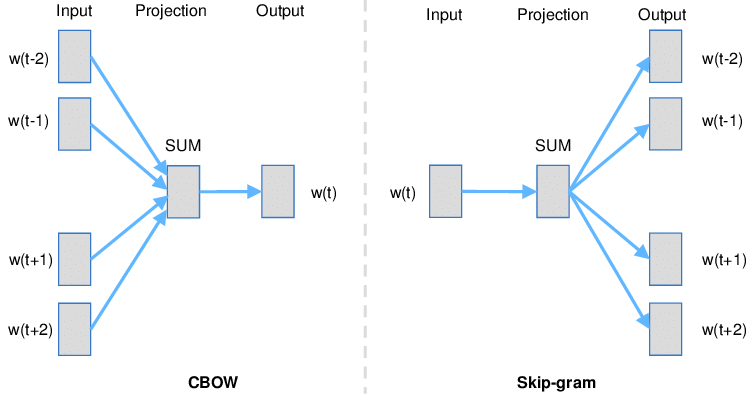

### Model Training using CBOW

Let's start training the model! Our corpus is definitely small, but let's explore the training process anyways.

In [10]:
sentences = SimpleIterator(train.data)

# Let's time training the model
if TRAIN_MODELS:
    start = time.time()
    cbow_model = Word2Vec(sentences=sentences, vector_size=100, window=6, min_count=10, workers=10,sg=0, epochs=2)
    end = time.time()
    cbow_train_time = end - start
    '''
    @param sentences: The sentences we want to train on, should be an iterable of iterables of strings
    @param vector_size: The dimension of the embeddings
    @param window: The context window length
    @param min_count: The minimum number of word occurrences for it to be included in the vocabulary, good to set higher in order to prevent overfitting
    @param sg: The training algorithm, either CBOW (sg=0) or skip gram (sg=1)
    @param epochs: The number of epochs
    '''
    cbow_model.save("cbow.model")
    cbow_model_wv = cbow_model.wv
    del cbow_model #Don't need to save the model in memory after training!
else:
    cbow_model = Word2Vec.load("cbow.model")
    cbow_model_wv = cbow_model.wv

Error in callback <function set_css at 0x13285f100> (for pre_run_cell), with arguments args (<ExecutionInfo object at 15f5a7750, raw_cell="sentences = SimpleIterator(train.data)

# Let's ti.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/word2vec-%20CBOW%2C%20SkipGram.ipynb#X30sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

Processing sentences: 100%|██████████| 11314/11314 [06:05<00:00, 30.98it/s]


Let's test the embeddings using one of our tasks - testing the relationships between words! Let's test to see if our algorithm has learned "king" - "man" + "woman" = queen

In [11]:
cbow_model_wv.most_similar(positive=['king', 'woman'], negative=['man'], topn=3)

Error in callback <function set_css at 0x13285f100> (for pre_run_cell), with arguments args (<ExecutionInfo object at 153df9390, raw_cell="cbow_model_wv.most_similar(positive=['king', 'woma.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/word2vec-%20CBOW%2C%20SkipGram.ipynb#X32sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

[('84', 0.9764270782470703),
 ('nov.', 0.9756759405136108),
 ('bennett', 0.9742719531059265)]

Hmm...doesn't look like it did too well. This is likely due to our dataset - not only is it small, but it is unlikely that the context of kings and queens was brought up in the fetch20newsgroup dataset. We'll explore this in more depth later in the Visualize section, but for now let's explore one of Gensim's pre-trained Word2Vec models.The model was trained on the Google News dataset, which contained about 100 billion words.

In [12]:
import gensim.downloader

google_wv = gensim.downloader.load("word2vec-google-news-300")

Error in callback <function set_css at 0x13285f100> (for pre_run_cell), with arguments args (<ExecutionInfo object at 15d6620d0, raw_cell="import gensim.downloader

google_wv = gensim.downl.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/word2vec-%20CBOW%2C%20SkipGram.ipynb#X34sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [13]:
google_wv.most_similar(positive=['king', 'woman'], negative=['man'], topn=3)

Error in callback <function set_css at 0x13285f100> (for pre_run_cell), with arguments args (<ExecutionInfo object at 15e7d93b0, raw_cell="google_wv.most_similar(positive=['king', 'woman'],.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/word2vec-%20CBOW%2C%20SkipGram.ipynb#X35sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

[('queen', 0.7118191719055176),
 ('monarch', 0.6189674139022827),
 ('princess', 0.5902431011199951)]

In [14]:
print("Google News dataset had ", len(google_wv.key_to_index), "unique words!")
print("On the other hand, we only have", len(cbow_model_wv.key_to_index), "unique words in our fetch20newsgroup dataset!")

Error in callback <function set_css at 0x13285f100> (for pre_run_cell), with arguments args (<ExecutionInfo object at 15d9d5c70, raw_cell="print("Google News dataset had ", len(google_wv.ke.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/word2vec-%20CBOW%2C%20SkipGram.ipynb#X36sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

Google News dataset had  3000000 unique words!
On the other hand, we only have 15634 unique words in our fetch20newsgroup dataset!


### Model Training using Skipgram

In [15]:
if TRAIN_MODELS:
    #CBOW model
    print('Time to train the CBOW model: {} mins'.format(round((cbow_train_time) / 60, 2)))

    #Skip Gram model
    start_time = time.time()
    sg_model = Word2Vec(sentences, vector_size=100, window=6, min_count=10, workers=10, sg=1, epochs=2)
    print('Time to train the SG model: {} mins'.format(round((time.time() - start_time) / 60, 2)))
    sg_model.save("sg.model")
    sg_model_wv = sg_model.wv
    del sg_model
else:
    sg_model = Word2Vec.load("sg.model")
    sg_model_wv = sg_model.wv


Error in callback <function set_css at 0x13285f100> (for pre_run_cell), with arguments args (<ExecutionInfo object at 15d608bd0, raw_cell="if TRAIN_MODELS:
    #CBOW model
    print('Time t.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/word2vec-%20CBOW%2C%20SkipGram.ipynb#X41sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

Time to train the CBOW model: 18.13 mins


Processing sentences: 100%|██████████| 11314/11314 [06:06<00:00, 30.84it/s]

Time to train the SG model: 18.25 mins


CBOW will train a bit quicker than SG for this small dataset. This difference in training times will scale with larger dataset sizes and window sizes, which is why for larger datasets (like the Google News dataset), CBOW is usually used. Let's look at performance of CBOW and SG on a common word in our fetch20 dataset, "computer". Let's print out the top 3 most similar words to it and compare performance.

In [16]:
word = "computer"
count = cbow_model_wv.get_vecattr(word, "count")

print("Appearances of ", word, ":", count)

# To find the top 3 most similar words to "electric" in CBOW and Skip-Gram models
cbow_similar = cbow_model_wv.most_similar(word, topn=3)
sg_similar = sg_model_wv.most_similar(word, topn=3)

print("CBOW:", cbow_similar)
print("SG:", sg_similar)


Error in callback <function set_css at 0x13285f100> (for pre_run_cell), with arguments args (<ExecutionInfo object at 15d6dfad0, raw_cell="word = "computer"
count = cbow_model_wv.get_vecatt.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/word2vec-%20CBOW%2C%20SkipGram.ipynb#X43sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

Appearances of  computer : 1298
CBOW: [('a&m', 0.9188867211341858), ('engineering', 0.9124150276184082), ('school', 0.9049702882766724)]
SG: [('engineering', 0.8697148561477661), ('electrical', 0.8441854119300842), ('math', 0.8314512372016907)]


The CBOW model has associated "computer" with broader, more general terms.The Skip-gram model, while also linking "computer" to 'engineering', goes further into specifics with 'electrical' and 'math'. These terms are more directly related to the field of computer science and its technical aspects. This demonstrates Skip-gram's ability to capture more specific, closely related contexts.
Now lets look at an uncommon word like "cryptography".

In [18]:
word = "cryptography"
count = cbow_model_wv.get_vecattr(word, "count")

print("Appearances of ", word, ":", count)

# To find the top 3 most similar words to "computer" in CBOW and Skip-Gram models
cbow_similar = cbow_model_wv.most_similar(word, topn=3)
sg_similar = sg_model_wv.most_similar(word, topn=3)

print("CBOW:", cbow_similar)
print("SG:", sg_similar)

Error in callback <function set_css at 0x13285f100> (for pre_run_cell), with arguments args (<ExecutionInfo object at 165c0dda0, raw_cell="word = "cryptography"
count = cbow_model_wv.get_ve.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/word2vec-%20CBOW%2C%20SkipGram.ipynb#X45sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

Appearances of  cryptography : 89
CBOW: [("women's", 0.9866252541542053), ('biological', 0.9827837347984314), ('providing', 0.9821847677230835)]
SG: [('initiative', 0.9337505102157593), ('"clipper', 0.9126864671707153), ('harmful', 0.9125319123268127)]


The CBOW model has associated "cryptography" with terms that seem more contextual or thematic rather than directly related to the technical aspects of cryptography. The Skip-gram model has yielded more specific and technically relevant outputs.

## Visualization

Let's analyze the performance issues we're having with our fetch20 Word2Vec model by visualizing the relationships between words! We'll choose a couple of targeted and random words and plot them on a graph. These words are all 100-dimensional vectors, so to visualize them properly we will reduce them to 2 dimensions using [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html). Let's choose some words to analyze, and print their occurences in our dataset. Let's also print the occurences in the Google News dataset, just to get a sense of what we're dealing with here.

In [19]:
words = ["electronic", "electric", "cryptography", "computer", "dog", "cat", "plate", "table", "dinner", "man", "woman", "king", "queen", "apple", "rule", "rain", "water", "bath"]
# print number of appearances of words in vocabulary
for word in words:
    print(word, cbow_model_wv.get_vecattr(word, "count"), google_wv.get_vecattr(word, "count"))

Error in callback <function set_css at 0x13285f100> (for pre_run_cell), with arguments args (<ExecutionInfo object at 165c0c3d0, raw_cell="words = ["electronic", "electric", "cryptography",.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/word2vec-%20CBOW%2C%20SkipGram.ipynb#X51sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

electronic 151 2997558
electric 70 2996487
cryptography 89 2911531
computer 1298 2998721
dog 126 2997957
cat 57 2994053
plate 45 2996585
table 84 2998243
dinner 23 2997344
man 578 2999749
woman 131 2999359
king 135 2993853
queen 19 2989709
apple 366 2986533
rule 188 2998350
rain 28 2997728
water 284 2999607
bath 14 2988107


Error in callback <function set_css at 0x13285f100> (for pre_run_cell), with arguments args (<ExecutionInfo object at 165c0ef90, raw_cell="# Let's visualize these words using t-SNE
from skl.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/word2vec-%20CBOW%2C%20SkipGram.ipynb#X52sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

CBOW model:


/Users/willbrennan/Desktop/Coding/school_repo/school_code/.venv/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


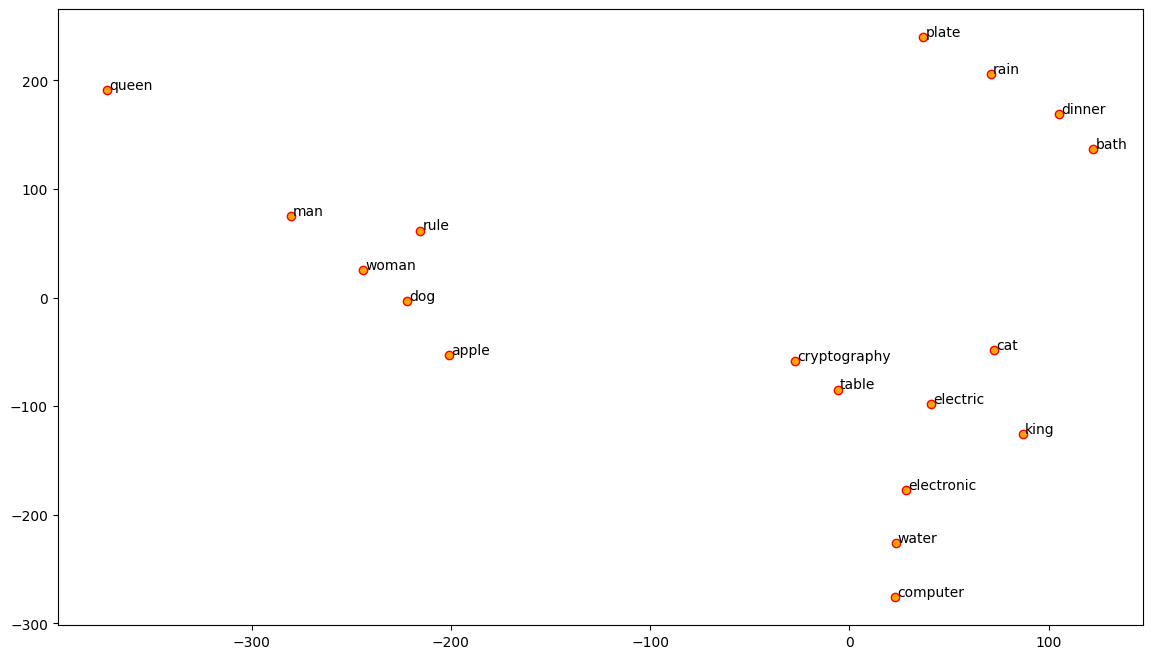

Skip-gram model:


/Users/willbrennan/Desktop/Coding/school_repo/school_code/.venv/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


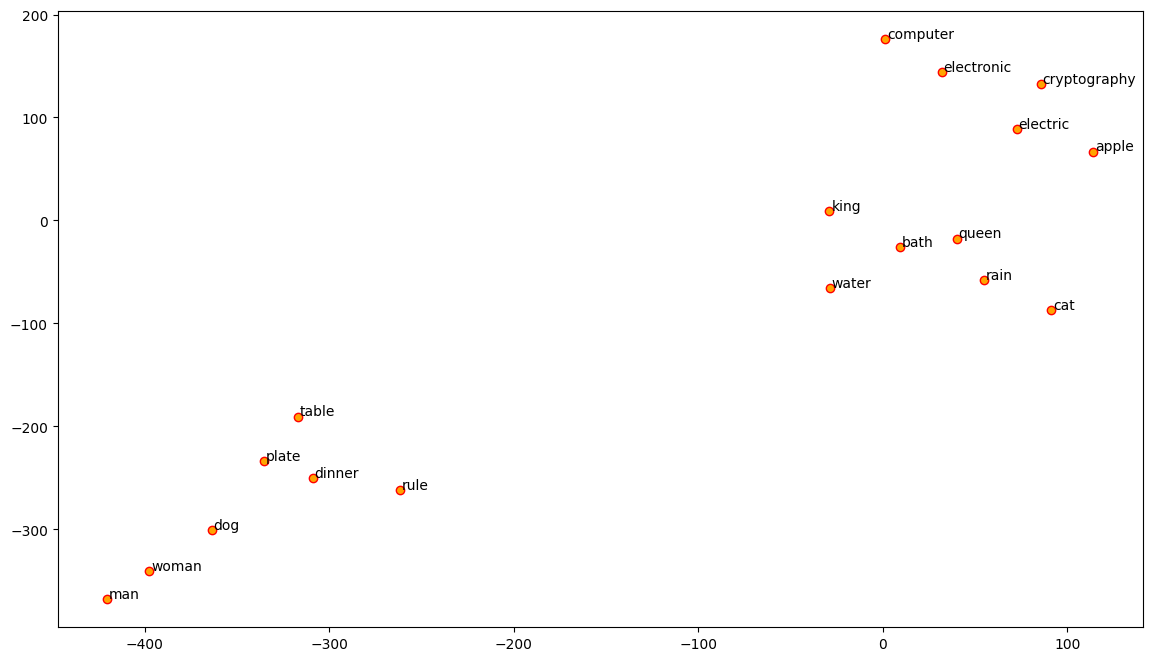

In [20]:
# Let's visualize these words using t-SNE
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

def plot_words(words, wv):
    word_vectors = np.array([wv[w] for w in words])
    tsne = TSNE(n_components=2, random_state=0, n_iter=10000, perplexity=2)
    np.set_printoptions(suppress=True)
    T = tsne.fit_transform(word_vectors)
    labels = words
    plt.figure(figsize=(14, 8))
    plt.scatter(T[:, 0], T[:, 1], c='orange', edgecolors='r')
    for label, x, y in zip(labels, T[:, 0], T[:, 1]):
        plt.annotate(label, xy=(x+1, y+1), xytext=(0, 0), textcoords='offset points')
    plt.show()

print("CBOW model:")
plot_words(words, cbow_model_wv)
print("Skip-gram model:")
plot_words(words, sg_model_wv)


Let's take a look at the Google news model to understand why it works so well. Feel free to edit the words list to try out any word combinations you like!

Error in callback <function set_css at 0x13285f100> (for pre_run_cell), with arguments args (<ExecutionInfo object at 15878bf50, raw_cell="print("Google news model:")
plot_words(words, goog.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/word2vec-%20CBOW%2C%20SkipGram.ipynb#X54sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

Google news model:


/Users/willbrennan/Desktop/Coding/school_repo/school_code/.venv/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


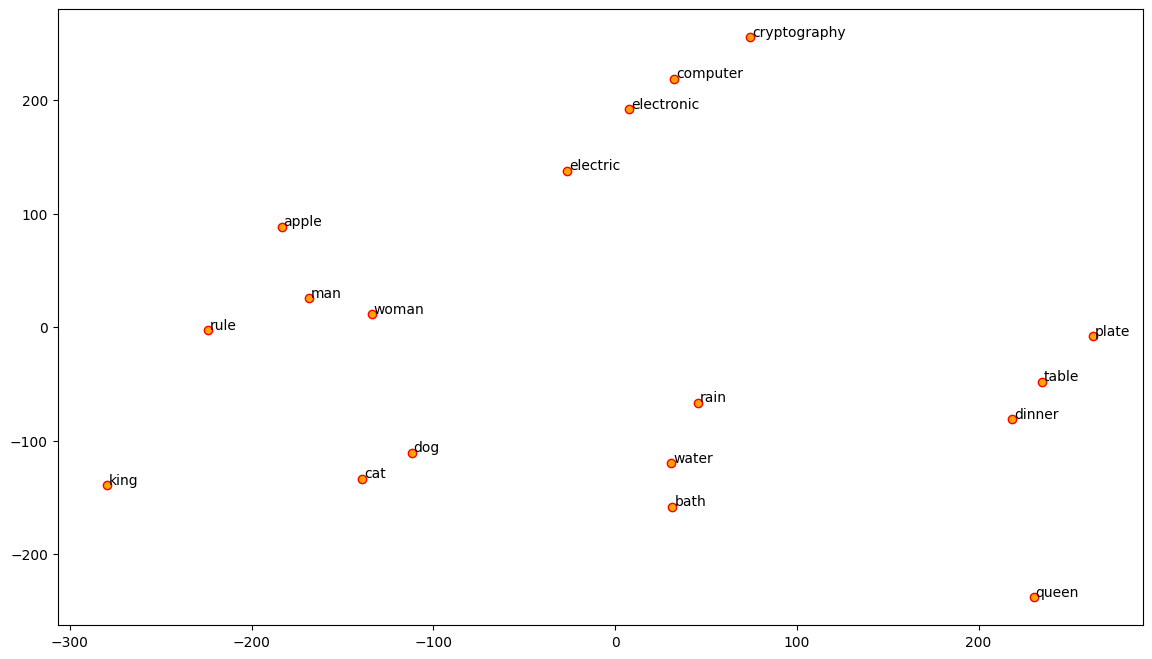

In [21]:
print("Google news model:")
plot_words(words, google_wv)

Wow! Words that are related all appear in related clusters. Much better performance!

## Practical Applications

One of the strengths of Word2Vec is it's simplicity for training for domain specific tasks. Word2Vec can be trained on any dataset of sentences and learns based on the contexts of those sentences, meaning with a large enough domain-specific corpus, it can gain a deep understanding of words in that context. Though fine-tuning a deep model like BERT is currently the state of the art for these tasks, Word2Vec is much simpler and less resource-intensive to train, for a lot of the same performance. This means Word2Vec is widely used for tasks such as: 
- Text Classification - Passing the word embeddings into machine learning models to classify into different categories
- Sentiment Analyis - Word embeddings can be used to analyze the sentiment of text, which can be useful for analyzing customer reviews or social media posts
- Question answering - Use word embeddings to find the meaning of questions and find relevant answers
- Machine Translation - Translate text from one language to another, can be achieved by representing words of different languages in a common vector space
- Recommendation systems - Use word embeddings to find similar products
- Find Human Biases - What human biases are present in large datasets? [Here](https://www.cs.cornell.edu/courses/cs4732/2017sp/Science%20article.pdf#:~:text=We%20replicated%20a%20spectrum%20of%20known%20biases%2C%20asmeasured,ofgender%20with%20respect%20to%20careers%20or%20first%20names.) is one that looks at the dataset we were looking at today, the Google News dataset.
- Knowledge discovery - Find new connections between words. [Here](https://www.nature.com/articles/s41586-019-1335-8) is an example of one paper using Word2Vec to discover new chemical compounds. 

Also note that unlike other algorithms we looked at in class, like tf-idf, LDAs, etc., Word2Vec technically does not need words to work. This is one advantage over even over BERT, especially for recommendation system use cases, where products themselves can be represented as a vector.

## Fun - Guess the word based on the similarity score

### Semantle

In [24]:
# choose a random word out of the fetch20newsgroup vocab
random_word = ""
#random_word = "computer"
while random_word not in google_wv.key_to_index or len(random_word) < 3:
    random_word = np.random.choice(list(cbow_model_wv.key_to_index.keys()))

wv_to_use = google_wv

print("Most similar word has a similarity score of {}.".format(wv_to_use.similarity(random_word, wv_to_use.most_similar(random_word)[0][0])))
print("1000th most similar word has a similarity score of {}.".format(wv_to_use.similarity(random_word, wv_to_use.most_similar(random_word, topn=1000)[999][0])))

word = input("Please enter guess. Enter 'q' to quit: ")
while word != 'q':
    if word.lower() == random_word.lower():
        print("Congratulations, you guessed the word!")
        break
    else:
        if word not in wv_to_use.key_to_index:
            print("Guess: " + word + ", Not a valid word for this dataset")
        else:
            s = "Guess: " + word + ", Similarity Score: " + str(wv_to_use.similarity(word, random_word))
            similar_words = [x[0] for x in wv_to_use.most_similar(random_word, topn=1000)]
            if word in similar_words:
                s += ", Only " + str(similar_words.index(word)) + " more similar words exist"
            print(s)

    word = input("Please enter guess. Enter 'q' to quit: ")

if word == 'q':
    print("Nice try! The word was: {}".format(random_word))

Error in callback <function set_css at 0x13285f100> (for pre_run_cell), with arguments args (<ExecutionInfo object at 15a06f850, raw_cell="# choose a random word out of the fetch20newsgroup.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/willbrennan/Desktop/Coding/school_repo/school_code/CSE%208803/toolbox/word2vec-%20CBOW%2C%20SkipGram.ipynb#X63sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

Most similar word has a similarity score of 0.7674919962882996.
1000th most similar word has a similarity score of 0.2652451992034912.
Guess: computer, Similarity Score: 0.05834756
Guess: tree, Similarity Score: 0.01797523
Guess: president, Similarity Score: 0.010945722
Guess: stop, Similarity Score: 0.07476391
Nice try! The word was: similar
